# Caso Practico: Isolation Forest para Deteccion de Anomalias en Sensores IoT

**Seminario: Algoritmos de Machine Learning — Tema 9**

| Campo | Detalle |
|---|---|
| Algoritmo | Isolation Forest |
| Dataset | synthetic_iot_dataset_challenging.csv |
| Registros | 3,000 (4 sensores DHT11) |
| Variables de entrada | Temperature, Humidity, Battery_Level |
| Variable objetivo | Anomaly (0 = normal, 1 = anomalia) |
| Tasa de anomalias | 17.4 % (522 de 3,000 registros) |

---

**Objetivo:** Detectar lecturas anomalas de sensores IoT de forma no supervisada,
utilizando el algoritmo Isolation Forest e interpretando sus resultados mediante
metricas de clasificacion estandar.


---
## Seccion 1 — Configuracion del Entorno

Se importan las librerias necesarias y se define la configuracion visual global.
El directorio de salida para las figuras se crea automaticamente si no existe.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
PALETTE = {'normal': '#2196F3', 'anomaly': '#F44336'}

OUTPUT_DIR = os.path.join('outputs', 'notebook')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


NumPy 2.4.6 | Pandas 3.0.3


---
## Seccion 2 — Carga y Exploracion del Dataset

El archivo `synthetic_iot_dataset_challenging.csv` contiene lecturas de cuatro
sensores DHT11 (temperatura y humedad). Las variables numericas ya estan
estandarizadas (media = 0, desviacion estandar = 1).

La columna `Anomaly` es el *ground truth*: etiqueta externa que indica si cada
lectura es una anomalia real (1) o un dato normal (0). Esta columna **no se
utiliza durante el entrenamiento** — Isolation Forest es un algoritmo no supervisado.


In [2]:
DATA_PATH = os.path.join('data', 'synthetic_iot_dataset_challenging.csv')
df = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print()
print(df.dtypes.to_string())
print()
print(df.head(6).to_string())
print()
vc = df['Anomaly'].value_counts()
print(f"Valores faltantes: {df.isnull().sum().sum()}")
print(f"Normal   (0): {vc[0]:>4d}  ({vc[0]/len(df)*100:.1f}%)")
print(f"Anomalia (1): {vc[1]:>4d}  ({vc[1]/len(df)*100:.1f}%)")


Dimensiones: 3000 filas x 5 columnas

Device_ID            str
Temperature      float64
Humidity         float64
Battery_Level    float64
Anomaly            int64

  Device_ID  Temperature  Humidity  Battery_Level  Anomaly
0   DHT11_B    -0.555734 -0.157264       0.377032        0
1   DHT11_A    -0.266879 -0.086229      -0.217410        0
2   DHT11_B     0.128544  0.041150       0.090479        0
3   DHT11_D    -1.001516 -0.320621      -0.705341        0
4   DHT11_D     0.311015  0.115365       0.807002        0
5   DHT11_D    -0.065368 -0.024232      -0.169044        0

Valores faltantes: 0
Normal   (0): 2478  (82.6%)
Anomalia (1):  522  (17.4%)


---
## Seccion 3 — Analisis Exploratorio de Datos (EDA)

Se visualizan las distribuciones de cada variable diferenciadas por etiqueta
(Normal / Anomalia) para evaluar la separabilidad de las clases.

**Figura 1:** Histogramas de densidad y boxplots por variable.
Si las distribuciones de ambas clases se superponen, el problema de deteccion
sera dificil independientemente del algoritmo utilizado.

**Figura 2:** Diagramas de dispersion bidimensionales con las etiquetas reales.
Permiten ver si las anomalias forman clusters o se mezclan con los datos normales.


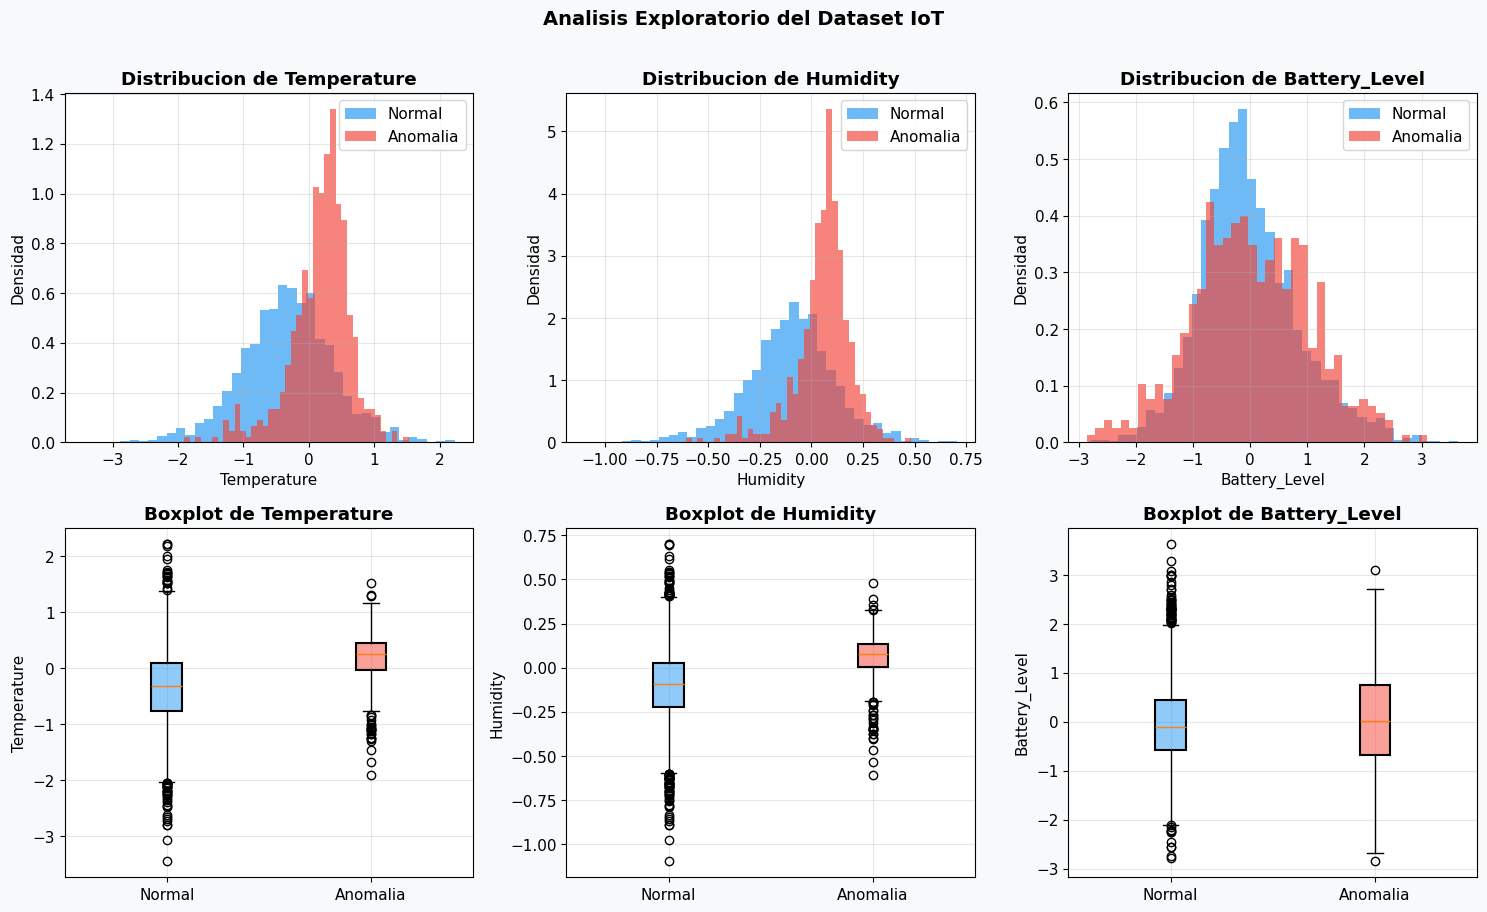

In [3]:
FEATURES = ['Temperature', 'Humidity', 'Battery_Level']
X = df[FEATURES].copy()
y = df['Anomaly'].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Analisis Exploratorio del Dataset IoT', fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(FEATURES):
    ax = axes[0, i]
    ax.hist(X[col][y == 0], bins=40, alpha=0.65, color=PALETTE['normal'], label='Normal', density=True)
    ax.hist(X[col][y == 1], bins=40, alpha=0.65, color=PALETTE['anomaly'], label='Anomalia', density=True)
    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend()

for i, col in enumerate(FEATURES):
    ax = axes[1, i]
    bp = ax.boxplot([X[col][y == 0].values, X[col][y == 1].values],
                    labels=['Normal', 'Anomalia'], patch_artist=True,
                    boxprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor(PALETTE['normal'] + '80')
    bp['boxes'][1].set_facecolor(PALETTE['anomaly'] + '80')
    ax.set_title(f'Boxplot de {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_eda.png'), dpi=150, bbox_inches='tight')
plt.show()


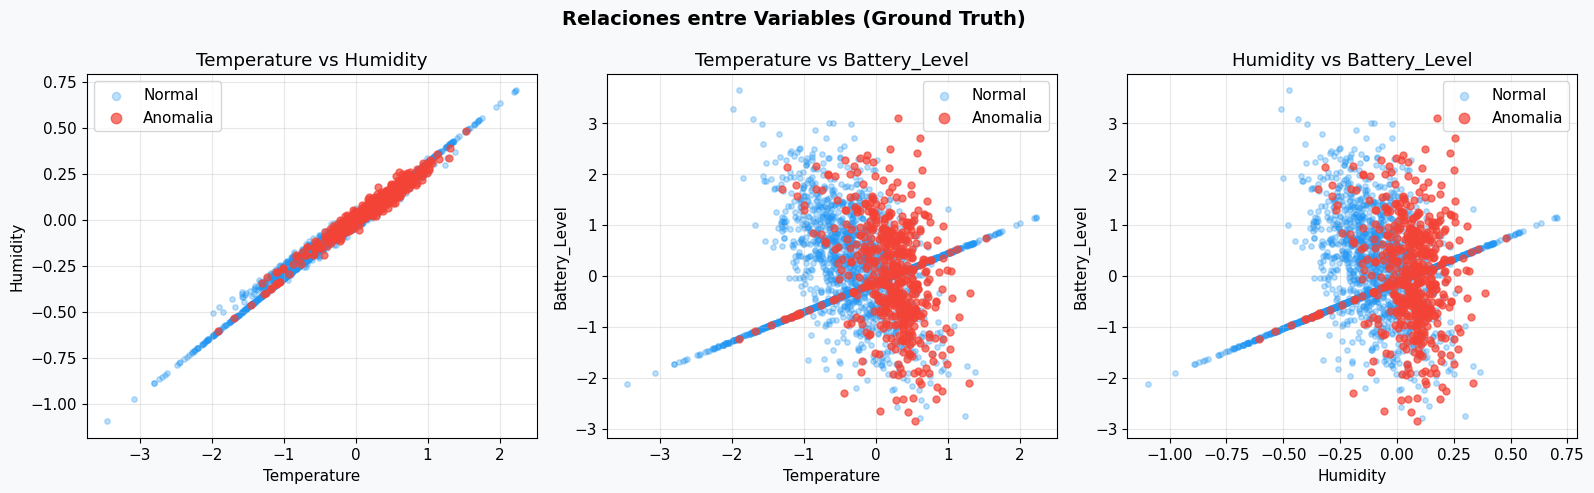

In [4]:
pairs = [('Temperature', 'Humidity'), ('Temperature', 'Battery_Level'), ('Humidity', 'Battery_Level')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relaciones entre Variables (Ground Truth)', fontsize=14, fontweight='bold')
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(X[x_col][y==0], X[y_col][y==0], c=PALETTE['normal'], alpha=0.3, s=15, label='Normal')
    ax.scatter(X[x_col][y==1], X[y_col][y==1], c=PALETTE['anomaly'], alpha=0.7, s=25, label='Anomalia', zorder=3)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(markerscale=1.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_scatter_ground_truth.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Seccion 4 — Fundamentos Matematicos del Isolation Forest

El algoritmo se basa en construir *iTrees* (arboles de aislamiento) mediante
cortes aleatorios en el espacio de caracteristicas.

### Longitud del camino h(x)

Para aislar un punto **x**, el arbol realiza cortes sucesivos hasta que x queda
aislado. La longitud del camino h(x) es el numero de cortes necesarios.

- **Anomalia:** h(x) pequeno (se aísla facilmente, esta en una zona despoblada)
- **Normal:** h(x) grande (se necesitan muchos cortes, esta dentro de un cluster)

### Funcion de normalizacion c(n)

Para comparar longitudes entre arboles de diferente tamano, se normaliza con c(n):
el camino medio de busqueda fallida en un Arbol de Busqueda Binaria (BST) de n nodos.

$$c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

donde $H(i) = \sum_{k=1}^{i}\frac{1}{k} \approx \ln(i) + 0.5772$

Con `max_samples = 256`: $c(256) \approx 10.25$

### Puntuacion de anomalia s(x, n)

$$s(x, n) = 2^{-\dfrac{E[h(x)]}{c(n)}}$$

| s(x, n) | Interpretacion |
|---|---|
| s -> 1 | Anomalia (h(x) muy corto respecto a c(n)) |
| s = 0.5 | Indeterminado (h(x) = c(n)) |
| s -> 0 | Normal (h(x) muy largo respecto a c(n)) |

### Relacion con scikit-learn

`decision_function(x)` devuelve un score desplazado: valores negativos indican
anomalia, valores positivos indican normal. La relacion aproximada es:

$$\text{decision\_function}(x) \approx -s(x, n) + 0.5$$


In [5]:
def euler_mascheroni_H(i):
    """Numero armonico H(i) = sum(1/k) para k=1..i"""
    return sum(1.0/k for k in range(1, i+1))

def c_n(n):
    """
    Longitud media de busqueda fallida en un BST de n nodos.
    c(n) = 2 * H(n-1) - 2*(n-1)/n
    """
    if n <= 1:
        return 1.0
    return 2 * euler_mascheroni_H(n - 1) - 2*(n-1)/n

def anomaly_score(h_x_expected, n):
    """s(x, n) = 2^(-E[h(x)] / c(n))"""
    return 2 ** (-h_x_expected / c_n(n))

n_demo = 256
c = c_n(n_demo)
print(f"Para n = {n_demo} (max_samples por defecto):")
print(f"  H(255) = {euler_mascheroni_H(255):.4f}")
print(f"  c(n)   = {c:.4f}")
print()
print(f"  {'h(x)':>8} | {'s(x,n)':>10} | {'Clasificacion':>15}")
print(f"  {'-'*8}-+-{'-'*10}-+-{'-'*15}")
for h_val in [1, 3, 5, 8, 10, c, 12, 14, 16]:
    s = anomaly_score(h_val, n_demo)
    label = "ANOMALIA" if s > 0.7 else ("Ambiguo" if s > 0.45 else "Normal")
    print(f"  {h_val:>8.1f} | {s:>10.4f} | {label:>15}")
print(f"\n  c(n) = {c:.4f}  ->  cuando h(x) = c(n), s = 0.5 (punto de equilibrio)")


Para n = 256 (max_samples por defecto):
  H(255) = 6.1204
  c(n)   = 10.2487

      h(x) |     s(x,n) |   Clasificacion
  ---------+------------+----------------
       1.0 |     0.9346 |        ANOMALIA
       3.0 |     0.8164 |        ANOMALIA
       5.0 |     0.7131 |        ANOMALIA
       8.0 |     0.5821 |         Ambiguo
      10.0 |     0.5085 |         Ambiguo
      10.2 |     0.5000 |         Ambiguo
      12.0 |     0.4441 |          Normal
      14.0 |     0.3880 |          Normal
      16.0 |     0.3389 |          Normal

  c(n) = 10.2487  ->  cuando h(x) = c(n), s = 0.5 (punto de equilibrio)


---
## Seccion 5 — Entrenamiento: Modelo Baseline

**Parametros:**

| Parametro | Valor | Descripcion |
|---|---|---|
| `n_estimators` | 100 | Numero de arboles en el bosque |
| `contamination` | `'auto'` | Umbral teorico: `decision_function = 0` equivale a `s = 0.5` |
| `max_samples` | `'auto'` | `min(256, n_muestras)` por arbol |
| `random_state` | 42 | Semilla para reproducibilidad |

Con `contamination='auto'`, el modelo no asume ninguna proporcion de anomalias.
El umbral de decision es el punto donde `decision_function(x) = 0`.


In [6]:
model_baseline = IsolationForest(
    n_estimators=100,
    contamination='auto',
    max_samples='auto',
    random_state=42
)
model_baseline.fit(X)

preds_b    = model_baseline.predict(X)
scores_b   = model_baseline.score_samples(X)
decision_b = model_baseline.decision_function(X)

anomalies_b = np.where(preds_b == -1)[0]
print(f"Anomalias detectadas: {len(anomalies_b)}  ({len(anomalies_b)/len(X)*100:.1f}%)")
print(f"Rango de decision_function: [{decision_b.min():.4f}, {decision_b.max():.4f}]")
print("Valores < 0 indican anomalia. Valores > 0 indican normal.")


Anomalias detectadas: 552  (18.4%)
Rango de decision_function: [-0.2608, 0.1185]
Valores < 0 indican anomalia. Valores > 0 indican normal.


---
## Seccion 6 — Entrenamiento: Modelo Mejorado y Modelo Optimo

Se entrenan dos modelos adicionales con parametros ajustados:

**Modelo Mejorado** (`contamination=0.05`): asume que el 5% de los datos son
anomalias. El umbral se ubica en el percentil 5 de los scores.

$$\text{umbral} = \text{percentil}_{5}(\{\text{decision\_function}(x_i)\})$$

**Modelo Optimo** (`contamination=0.174`): contamination ajustado a la tasa real
de anomalias del dataset (17.4%). Permite evaluar el efecto del parametro cuando
se conoce la proporcion real a priori.


In [7]:
model_improved = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples=256,
    bootstrap=False,
    random_state=42
)
model_improved.fit(X)

preds_i    = model_improved.predict(X)
scores_i   = model_improved.score_samples(X)
decision_i = model_improved.decision_function(X)

print(f"Modelo Mejorado — Anomalias detectadas: {np.sum(preds_i == -1)}  ({np.mean(preds_i == -1)*100:.1f}%)")

model_optimal = IsolationForest(
    n_estimators=200,
    contamination=0.174,
    max_samples=256,
    bootstrap=False,
    random_state=42
)
model_optimal.fit(X)

preds_o    = model_optimal.predict(X)
decision_o = model_optimal.decision_function(X)

print(f"Modelo Optimo  — Anomalias detectadas: {np.sum(preds_o == -1)}  ({np.mean(preds_o == -1)*100:.1f}%)")


Modelo Mejorado — Anomalias detectadas: 150  (5.0%)


Modelo Optimo  — Anomalias detectadas: 522  (17.4%)


---
## Seccion 7 — Distribucion de Puntuaciones

**Figura 3:** Distribucion de scores (`decision_function`) separados por clase
predicha. La linea negra marca el umbral de decision (score = 0).
El traslape entre las distribuciones indica dificultad de separacion.

**Figura 4:** Distribucion de scores por clase *real* (ground truth).
Cuando las dos distribuciones se superponen, el AUC del modelo sera bajo.


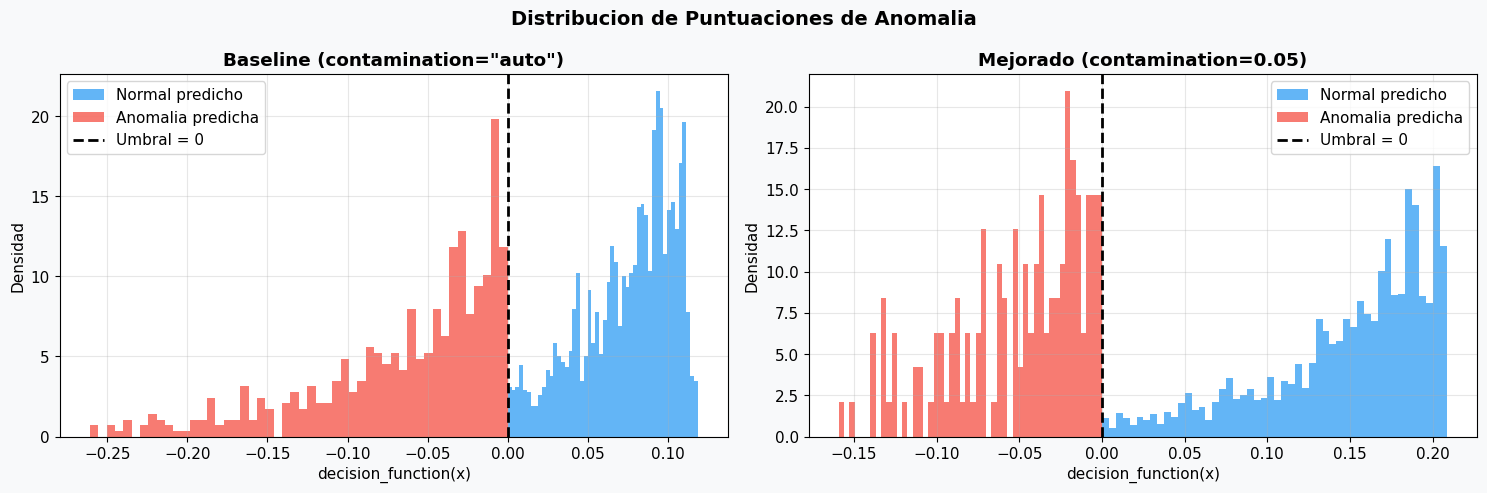

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribucion de Puntuaciones de Anomalia', fontsize=14, fontweight='bold')

for ax, (scores, preds, title) in zip(axes, [
    (decision_b, preds_b, 'Baseline (contamination="auto")'),
    (decision_i, preds_i, 'Mejorado (contamination=0.05)')
]):
    ax.hist(scores[preds == 1],  bins=50, alpha=0.7, color=PALETTE['normal'],
            label='Normal predicho', density=True)
    ax.hist(scores[preds == -1], bins=50, alpha=0.7, color=PALETTE['anomaly'],
            label='Anomalia predicha', density=True)
    ax.axvline(0.0, color='black', linewidth=2, linestyle='--', label='Umbral = 0')
    ax.set_xlabel('decision_function(x)')
    ax.set_ylabel('Densidad')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


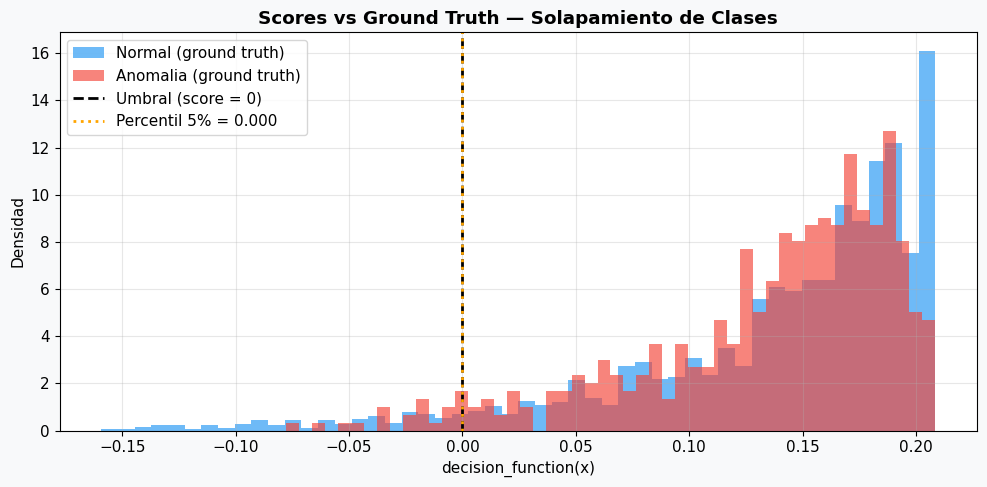

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(decision_i[y == 0], bins=50, alpha=0.65, color=PALETTE['normal'],
        label='Normal (ground truth)', density=True)
ax.hist(decision_i[y == 1], bins=50, alpha=0.65, color=PALETTE['anomaly'],
        label='Anomalia (ground truth)', density=True)
ax.axvline(0.0, color='black', linewidth=2, linestyle='--', label='Umbral (score = 0)')
q5 = np.percentile(decision_i, 5)
ax.axvline(q5, color='orange', linewidth=2, linestyle=':', label=f'Percentil 5% = {q5:.3f}')
ax.set_xlabel('decision_function(x)')
ax.set_ylabel('Densidad')
ax.set_title('Scores vs Ground Truth — Solapamiento de Clases', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_score_vs_ground_truth.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Seccion 8 — Evaluacion con Metricas de Clasificacion

Las predicciones del modelo (escala -1/+1) se convierten a la escala binaria
estandar (1/0) para comparar con el ground truth.

**Metricas calculadas:**

- **Precision** = TP / (TP + FP): fraccion de alertas que son anomalias reales
- **Recall** = TP / (TP + FN): fraccion de anomalias reales detectadas
- **F1-Score** = media armonica de Precision y Recall
- **ROC-AUC**: capacidad del score continuo de rankear anomalias sobre normales.
  Independiente del umbral. Valor de referencia: 0.5 = aleatorio, 1.0 = perfecto.

**Nota sobre ROC-AUC:** se niega el score (`-decision_function`) porque valores
mas negativos corresponden a anomalias, y `roc_auc_score` espera valores mas altos
para la clase positiva.

**Figura 5:** Matrices de confusion de los tres modelos comparados.


In [10]:
def evaluate_model(name, preds, scores, y_true):
    """Calcula precision, recall, F1 y ROC-AUC. Devuelve dict con resultados."""
    preds_binary = (preds == -1).astype(int)
    tp = int(np.sum((preds_binary == 1) & (y_true == 1)))
    fp = int(np.sum((preds_binary == 1) & (y_true == 0)))
    fn = int(np.sum((preds_binary == 0) & (y_true == 1)))
    tn = int(np.sum((preds_binary == 0) & (y_true == 0)))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    # Se niegan los scores: decision_function mas negativo = mas anomalo
    roc_auc   = roc_auc_score(y_true, -scores)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  TP={tp:>4}  FP={fp:>4}  FN={fn:>4}  TN={tn:>4}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Anomalias detectadas: {tp+fp}  ({(tp+fp)/len(preds)*100:.1f}%)")
    return {'name': name, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'precision': precision, 'recall': recall, 'f1': f1,
            'roc_auc': roc_auc, 'preds_binary': preds_binary}

metrics_b = evaluate_model("Baseline (contamination='auto')", preds_b, decision_b, y)
metrics_i = evaluate_model("Mejorado (contamination=0.05)",   preds_i, decision_i, y)
metrics_o = evaluate_model("Optimo   (contamination=0.174)",  preds_o, decision_o, y)



──────────────────────────────────────────────────
  Baseline (contamination='auto')
──────────────────────────────────────────────────
  TP=  91  FP= 461  FN= 431  TN=2017
  Precision : 0.1649
  Recall    : 0.1743
  F1-Score  : 0.1695
  ROC-AUC   : 0.5519
  Anomalias detectadas: 552  (18.4%)

──────────────────────────────────────────────────
  Mejorado (contamination=0.05)
──────────────────────────────────────────────────
  TP=  20  FP= 130  FN= 502  TN=2348
  Precision : 0.1333
  Recall    : 0.0383
  F1-Score  : 0.0595
  ROC-AUC   : 0.5579
  Anomalias detectadas: 150  (5.0%)

──────────────────────────────────────────────────
  Optimo   (contamination=0.174)
──────────────────────────────────────────────────
  TP=  90  FP= 432  FN= 432  TN=2046
  Precision : 0.1724
  Recall    : 0.1724
  F1-Score  : 0.1724
  ROC-AUC   : 0.5579
  Anomalias detectadas: 522  (17.4%)


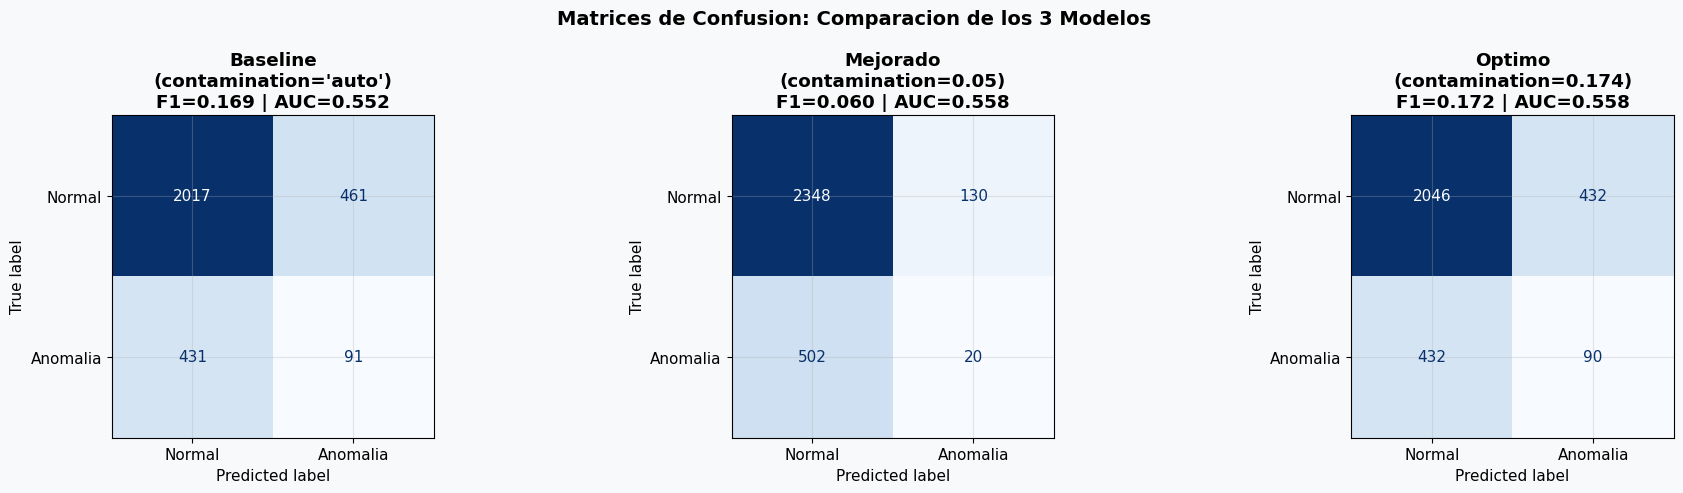

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Matrices de Confusion: Comparacion de los 3 Modelos', fontsize=14, fontweight='bold')

for ax, metrics, title in zip(axes,
    [metrics_b, metrics_i, metrics_o],
    ["Baseline\n(contamination='auto')",
     'Mejorado\n(contamination=0.05)',
     'Optimo\n(contamination=0.174)']):
    cm = np.array([[metrics['tn'], metrics['fp']],
                   [metrics['fn'], metrics['tp']]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalia'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nF1={metrics["f1"]:.3f} | AUC={metrics["roc_auc"]:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Seccion 9 — Visualizacion Espacial de Predicciones

**Figura 6:** Diagrama de dispersion con los cuatro resultados posibles:
- TP (verde): anomalias correctamente detectadas
- FP (naranja): falsas alarmas (datos normales clasificados como anomalia)
- FN (morado): anomalias no detectadas
- TN (azul): datos normales correctamente clasificados

**Figura 7:** Serie temporal de temperatura con las anomalias marcadas.
Panel superior: ground truth. Panel inferior: predicciones del modelo.


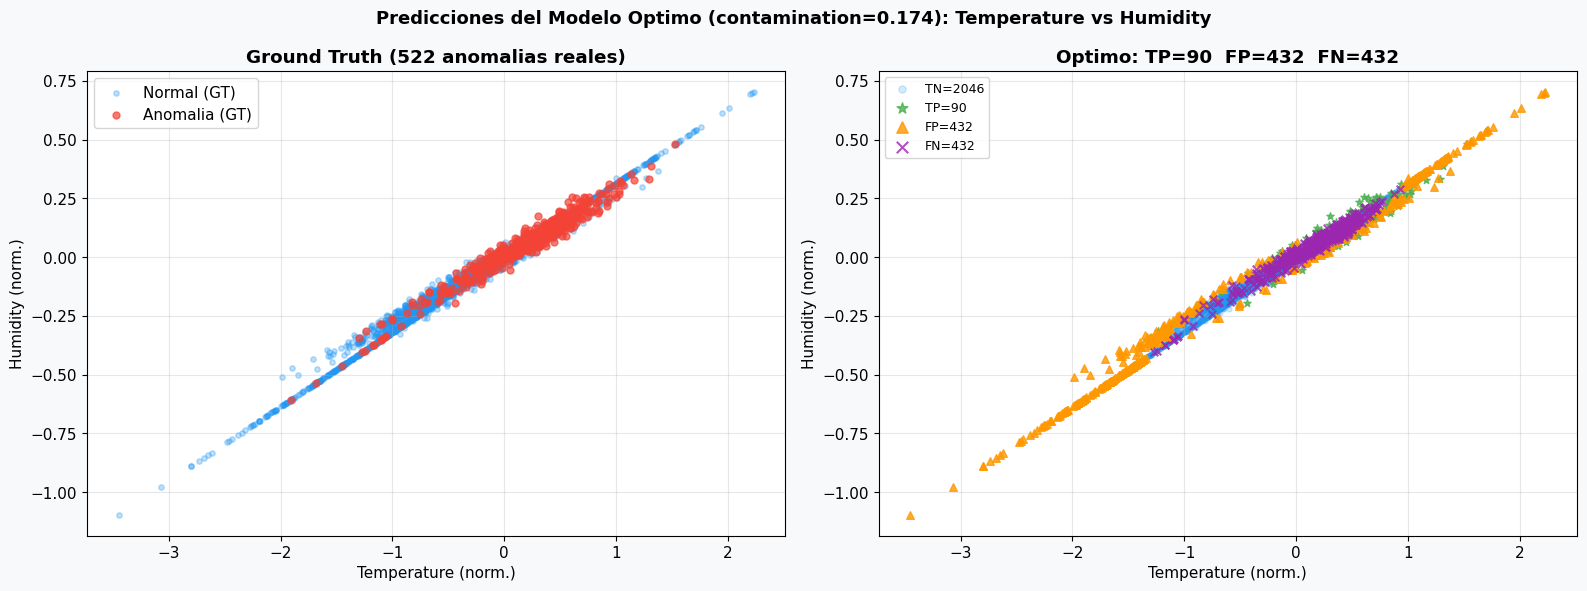

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Predicciones del Modelo Optimo (contamination=0.174): Temperature vs Humidity',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(X['Temperature'][y==0], X['Humidity'][y==0],
           c=PALETTE['normal'], alpha=0.3, s=15, label='Normal (GT)')
ax.scatter(X['Temperature'][y==1], X['Humidity'][y==1],
           c=PALETTE['anomaly'], alpha=0.7, s=25, label='Anomalia (GT)', zorder=3)
ax.set_title('Ground Truth (522 anomalias reales)', fontweight='bold')
ax.set_xlabel('Temperature (norm.)')
ax.set_ylabel('Humidity (norm.)')
ax.legend()

ax = axes[1]
preds_bin_o = metrics_o['preds_binary']
y_arr       = y.values
tp_mask = (preds_bin_o == 1) & (y_arr == 1)
fp_mask = (preds_bin_o == 1) & (y_arr == 0)
fn_mask = (preds_bin_o == 0) & (y_arr == 1)
tn_mask = (preds_bin_o == 0) & (y_arr == 0)
ax.scatter(X['Temperature'][tn_mask], X['Humidity'][tn_mask],
           c='#2196F3', alpha=0.2, s=12, label=f'TN={tn_mask.sum()}')
ax.scatter(X['Temperature'][tp_mask], X['Humidity'][tp_mask],
           c='#4CAF50', alpha=0.8, s=30, label=f'TP={tp_mask.sum()}', marker='*', zorder=4)
ax.scatter(X['Temperature'][fp_mask], X['Humidity'][fp_mask],
           c='#FF9800', alpha=0.8, s=30, label=f'FP={fp_mask.sum()}', marker='^', zorder=4)
ax.scatter(X['Temperature'][fn_mask], X['Humidity'][fn_mask],
           c='#9C27B0', alpha=0.8, s=30, label=f'FN={fn_mask.sum()}', marker='x', zorder=4)
ax.set_title(f'Optimo: TP={tp_mask.sum()}  FP={fp_mask.sum()}  FN={fn_mask.sum()}', fontweight='bold')
ax.set_xlabel('Temperature (norm.)')
ax.set_ylabel('Humidity (norm.)')
ax.legend(markerscale=1.5, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_predictions_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


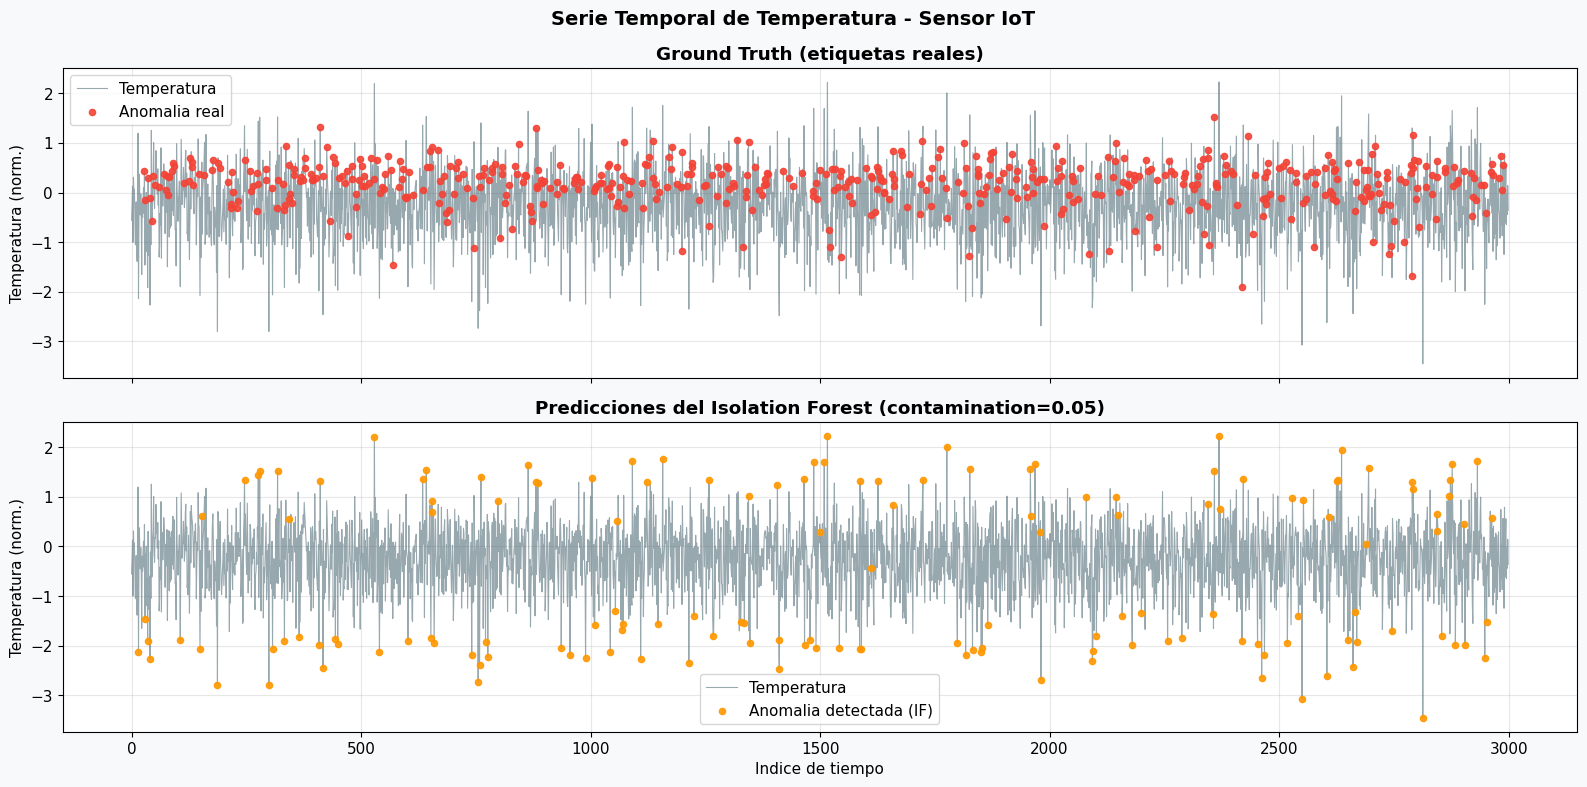

In [13]:
temp_series       = X['Temperature'].values
anomaly_mask_gt   = y.values.astype(bool)
anomaly_mask_pred = (preds_i == -1)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Serie Temporal de Temperatura - Sensor IoT', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(temp_series, color='#546E7A', alpha=0.6, linewidth=0.8, label='Temperatura')
ax.scatter(np.where(anomaly_mask_gt)[0], temp_series[anomaly_mask_gt],
           c=PALETTE['anomaly'], s=20, zorder=3, label='Anomalia real', alpha=0.9)
ax.set_title('Ground Truth (etiquetas reales)', fontweight='bold')
ax.set_ylabel('Temperatura (norm.)')
ax.legend()

ax = axes[1]
ax.plot(temp_series, color='#546E7A', alpha=0.6, linewidth=0.8, label='Temperatura')
ax.scatter(np.where(anomaly_mask_pred)[0], temp_series[anomaly_mask_pred],
           c='#FF9800', s=20, zorder=3, label='Anomalia detectada (IF)', alpha=0.9)
ax.set_title('Predicciones del Isolation Forest (contamination=0.05)', fontweight='bold')
ax.set_ylabel('Temperatura (norm.)')
ax.set_xlabel('Indice de tiempo')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '07_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Seccion 10 — Analisis de Sensibilidad a Parametros

**Figura 8:** Efecto del parametro `contamination` sobre F1, Precision y Recall.
Permite identificar el valor optimo empirico para este dataset.

**Figura 9:** Convergencia del modelo en funcion del numero de arboles (`n_estimators`).
El F1 se estabiliza a partir de ~100 arboles; usar 200 es un balance adecuado.


Calculando sensibilidad al parametro contamination...


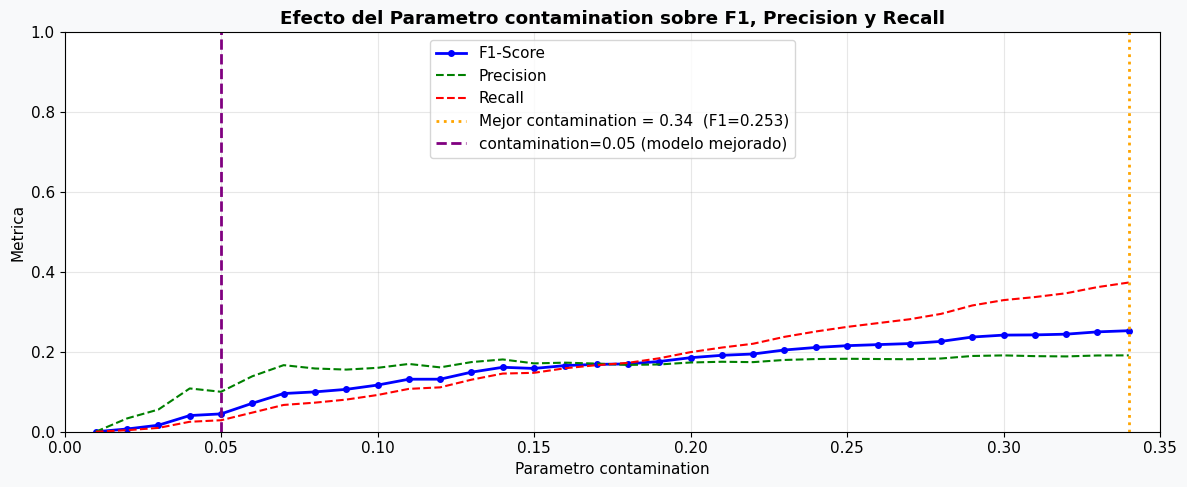

Mejor contamination: 0.34  ->  F1 = 0.2529

Calculando efecto de n_estimators...


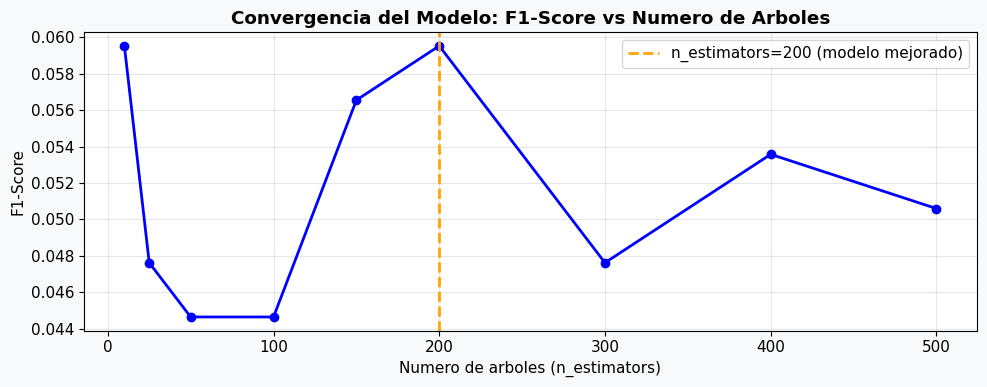

In [14]:
print("Calculando sensibilidad al parametro contamination...")
contam_values    = np.arange(0.01, 0.35, 0.01)
f1_scores        = []
precision_scores = []
recall_scores    = []

for c_val in contam_values:
    m = IsolationForest(n_estimators=100, contamination=c_val, max_samples=256, random_state=42)
    m.fit(X)
    p_bin = (m.predict(X) == -1).astype(int)
    f1_scores.append(f1_score(y, p_bin, zero_division=0))
    precision_scores.append(precision_score(y, p_bin, zero_division=0))
    recall_scores.append(recall_score(y, p_bin, zero_division=0))

best_idx    = np.argmax(f1_scores)
best_contam = contam_values[best_idx]
best_f1     = f1_scores[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(contam_values, f1_scores,        'b-o', markersize=4, linewidth=2, label='F1-Score')
ax.plot(contam_values, precision_scores, 'g--', linewidth=1.5, label='Precision')
ax.plot(contam_values, recall_scores,    'r--', linewidth=1.5, label='Recall')
ax.axvline(best_contam, color='orange', linewidth=2, linestyle=':',
           label=f'Mejor contamination = {best_contam:.2f}  (F1={best_f1:.3f})')
ax.axvline(0.05, color='purple', linewidth=2, linestyle='--',
           label='contamination=0.05 (modelo mejorado)')
ax.set_xlabel('Parametro contamination')
ax.set_ylabel('Metrica')
ax.set_title('Efecto del Parametro contamination sobre F1, Precision y Recall', fontweight='bold')
ax.legend()
ax.set_xlim(0, 0.35)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_contamination_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mejor contamination: {best_contam:.2f}  ->  F1 = {best_f1:.4f}")

print("\nCalculando efecto de n_estimators...")
n_trees  = [10, 25, 50, 100, 150, 200, 300, 400, 500]
f1_trees = []
for n in n_trees:
    m = IsolationForest(n_estimators=n, contamination=0.05, max_samples=256, random_state=42)
    m.fit(X)
    p = (m.predict(X) == -1).astype(int)
    f1_trees.append(f1_score(y, p, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_trees, f1_trees, 'b-o', markersize=6, linewidth=2)
ax.axvline(200, color='orange', linewidth=2, linestyle='--', label='n_estimators=200 (modelo mejorado)')
ax.set_xlabel('Numero de arboles (n_estimators)')
ax.set_ylabel('F1-Score')
ax.set_title('Convergencia del Modelo: F1-Score vs Numero de Arboles', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '09_n_estimators_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Seccion 11 — Tabla Comparativa de Resultados


In [15]:
models = [metrics_b, metrics_i, metrics_o]
print("=" * 75)
print("RESUMEN FINAL DEL EXPERIMENTO — 3 MODELOS")
print("=" * 75)
print(f"Dataset: {DATA_PATH}")
print(f"  Registros: {len(df):,}  |  Anomalias reales: {int(y.sum())} ({y.mean()*100:.1f}%)")
print(f"\n{'Metrica':<28} {'Baseline':>12} {'Mejorado':>12} {'Optimo':>12}")
print("-" * 68)
for key, label in [('precision','Precision'), ('recall','Recall'),
                   ('f1','F1-Score'), ('roc_auc','ROC-AUC')]:
    print(f"  {label:<26} {models[0][key]:>12.4f} {models[1][key]:>12.4f} {models[2][key]:>12.4f}")
print("-" * 68)
for key, label in [('tp','TP'), ('fp','FP (falsas alarmas)'), ('fn','FN (no detectadas)')]:
    print(f"  {label:<26} {models[0][key]:>12} {models[1][key]:>12} {models[2][key]:>12}")
print("-" * 68)
print(f"  {'Anomalias detectadas':<26} "
      f"{models[0]['tp']+models[0]['fp']:>12} "
      f"{models[1]['tp']+models[1]['fp']:>12} "
      f"{models[2]['tp']+models[2]['fp']:>12}")


RESUMEN FINAL DEL EXPERIMENTO — 3 MODELOS
Dataset: data/synthetic_iot_dataset_challenging.csv
  Registros: 3,000  |  Anomalias reales: 522 (17.4%)

Metrica                          Baseline     Mejorado       Optimo
--------------------------------------------------------------------
  Precision                        0.1649       0.1333       0.1724
  Recall                           0.1743       0.0383       0.1724
  F1-Score                         0.1695       0.0595       0.1724
  ROC-AUC                          0.5519       0.5579       0.5579
--------------------------------------------------------------------
  TP                                   91           20           90
  FP (falsas alarmas)                 461          130          432
  FN (no detectadas)                  431          502          432
--------------------------------------------------------------------
  Anomalias detectadas                552          150          522


---
## Seccion 12 — Conclusiones del Experimento

### Resultados obtenidos

| Modelo | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|
| Baseline (contamination='auto') | 0.165 | 0.174 | 0.170 | 0.552 |
| Mejorado (contamination=0.05) | 0.133 | 0.038 | 0.060 | 0.558 |
| Optimo (contamination=0.174) | 0.172 | 0.172 | 0.172 | 0.558 |

### Analisis de los resultados

El ROC-AUC de 0.55 (cercano al valor aleatorio de 0.5) indica que los scores
generados por el modelo apenas superan al azar en la separacion de las clases.

**Causa:** Las anomalias del dataset se generaron solapadas con los datos normales
en el espacio de las tres variables (Temperature, Humidity, Battery_Level).
El nombre del archivo — *challenging* — es intencional.

Independientemente del valor de `contamination`, el techo del algoritmo esta
limitado por la separabilidad intrinseca de las clases, que el AUC mide
de forma independiente al umbral de decision.

### Cuando funciona mejor Isolation Forest

- Anomalias puntuales en zonas de baja densidad del espacio de datos
- Anomalias con valores extremos en alguna dimension
- Datasets de alta dimensionalidad donde las anomalias son escasas

### Mejoras propuestas para produccion

1. **Ingenieria de features:** agregar tasa de cambio (delta temporal),
   varianza local y desviacion respecto a la media historica del sensor
2. **Umbral dinamico por dispositivo** en lugar de un umbral global
3. **Combinacion con LOF** (Local Outlier Factor) como ensemble
4. **Retroalimentacion supervisada:** etiquetar anomalias confirmadas y re-entrenar

---
### Referencias

1. Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. IEEE ICDM, 413-422.
2. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825-2830.
3. Liu, F. T. et al. (2012). *Isolation-Based Anomaly Detection*. ACM TKDD, 6(1), 1-39.
